# AI-Assisted Transcriptomic Analysis — Live Demo

Run the **Setup** cell first (takes ~30-60s in Colab). After that, everything below is ready to demo:

1. **Figure Replication** — paste a photo of a published figure into the chat with Claude, describe `adata` (already loaded below), and paste the code Claude gives you into any open slot.
2. **Differential Expression & Enrichment** — pre-run examples, ready to riff on live.
3. **Clustering, Cell-Typing & Trajectory** — pre-run examples, ready to riff on live.
4. **Spatial Transcriptomics (Visium)** — a small real Visium dataset (`vdata`), with its own setup cell and open slots for live spatial figure replication.

See the prompt cheat-sheet at the bottom for example asks.

## Setup (run this first)

In [1]:
!pip install -q scanpy leidenalg gseapy python-igraph

import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor='white')

# Load the classic 10x PBMC 3k single-cell dataset (built into scanpy)
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()

# Standard QC + preprocessing
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs.pct_counts_mt < 20, :].copy()

adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata, resolution=0.5)
sc.tl.umap(adata)

print(adata)
print('\nClusters:', adata.obs['leiden'].value_counts().to_dict())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.5/230.5 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.

/tmp/ipykernel_4190/3902699951.py:10: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, facecolor='white')


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

/usr/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_4190/3902699951.py:34: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


AnnData object with n_obs × n_vars = 2698 × 1865
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: None (.X), 'counts'

Clusters: {'0': 1200, '1': 651, '2': 444, '3': 346, '4': 36, '5': 13, '6': 8}


---
## Section 1 — Figure Replication (live)

**How to use:** show Claude a photo of the target figure from a paper, tell it you have `adata` (an AnnData object, log-normalized, with `adata.obs['leiden']` clusters and a UMAP already computed at `adata.obsm['X_umap']`, raw log-normalized expression in `adata.raw`). Paste the code it gives you into the next open slot below and run it. Each slot is a plain, empty landing spot — not tied to any particular figure type — so whatever kind of figure you're shown, the generated code can go in the next one and just work.

### Figure replication — slot 1

In [ ]:
# Paste generated code here


### Figure replication — slot 2

In [ ]:
# Paste generated code here


### Figure replication — slot 3

In [ ]:
# Paste generated code here


### Figure replication — slot 4

In [ ]:
# Paste generated code here


### Figure replication — slot 5

In [ ]:
# Paste generated code here


---
## Section 2 — Differential Expression & Enrichment

Pre-run example: marker genes per cluster (stand-in for a DE comparison), a volcano-style plot, and a gene-set enrichment call. Ask Claude to adapt or restyle any of these live.

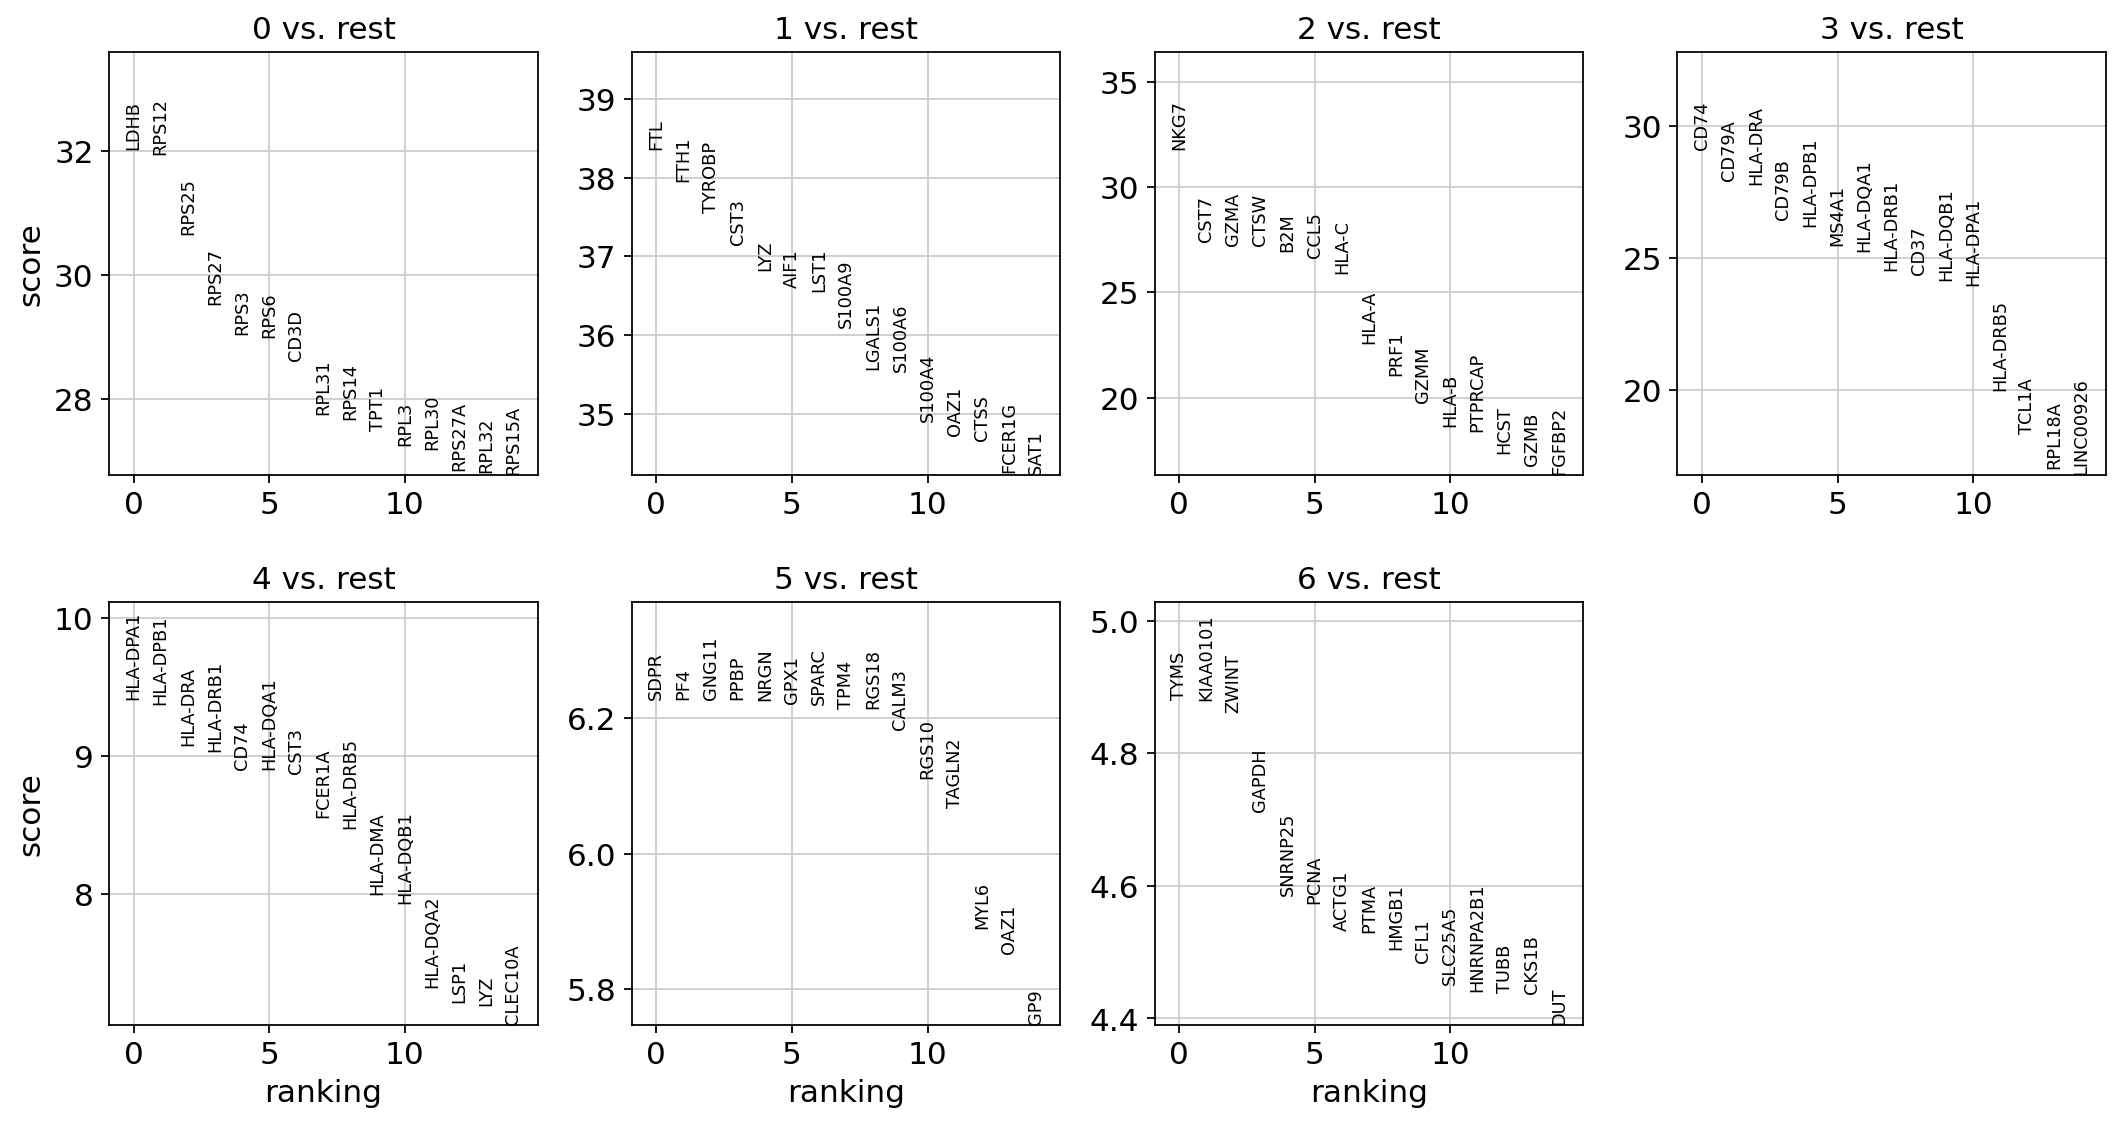

In [2]:
# Rank marker genes per cluster (Wilcoxon test) — the scRNA-seq analog of a DE comparison
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=15, sharey=False)

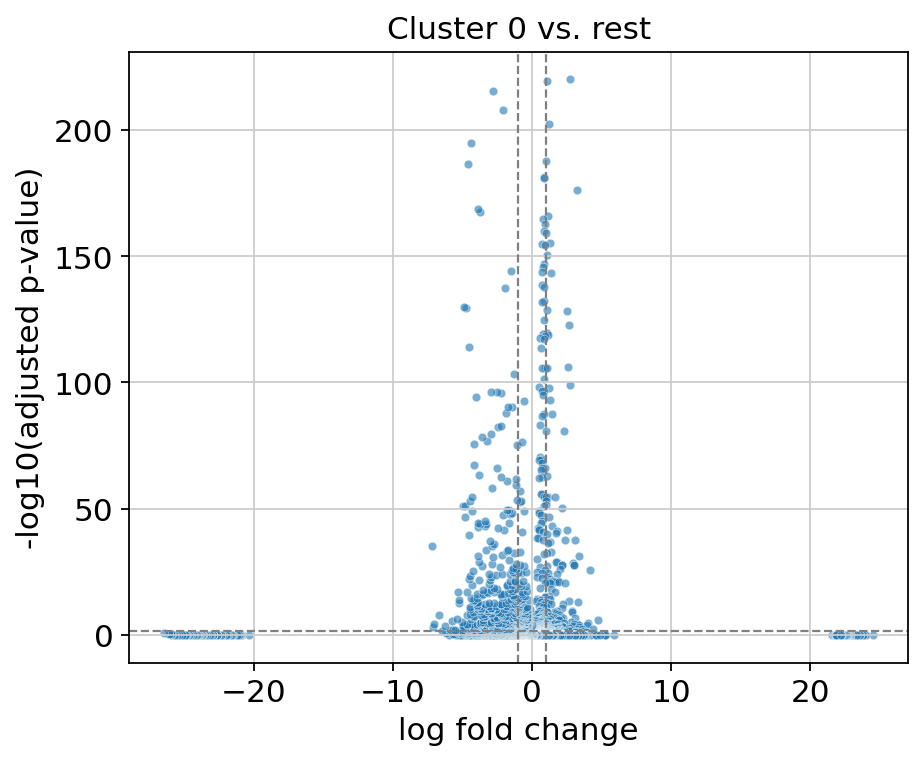

In [3]:
# Volcano-style plot for one cluster vs. rest
cluster_of_interest = '0'
result = adata.uns['rank_genes_groups']
de_df = pd.DataFrame({
    'gene': result['names'][cluster_of_interest],
    'logfoldchange': result['logfoldchanges'][cluster_of_interest],
    'pval_adj': result['pvals_adj'][cluster_of_interest],
})
de_df['neg_log10_padj'] = -np.log10(de_df['pval_adj'].clip(lower=1e-300))

plt.figure(figsize=(6, 5))
sns.scatterplot(data=de_df, x='logfoldchange', y='neg_log10_padj', s=15, alpha=0.6)
plt.axhline(-np.log10(0.05), color='grey', linestyle='--', linewidth=1)
plt.axvline(1, color='grey', linestyle='--', linewidth=1)
plt.axvline(-1, color='grey', linestyle='--', linewidth=1)
plt.xlabel('log fold change')
plt.ylabel('-log10(adjusted p-value)')
plt.title(f'Cluster {cluster_of_interest} vs. rest')
plt.tight_layout()
plt.show()

In [4]:
# Gene-set enrichment on the top marker genes for one cluster (requires internet access in Colab)
import gseapy as gp

top_genes = de_df.sort_values('pval_adj').head(50)['gene'].tolist()

try:
    enrich = gp.enrichr(
        gene_list=top_genes,
        gene_sets=['GO_Biological_Process_2021'],
        organism='human',
        outdir=None,
    )
    display(enrich.results.sort_values('Adjusted P-value').head(10))
except Exception as e:
    print('Enrichment call failed (likely no internet access in this environment):', e)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,SRP-dependent cotranslational protein targetin...,32/90,2.561552e-65,1.298707e-62,0,0,609.716475,90681.556849,RPL30;RPL3;RPL32;RPL31;RPLP0;RPL11;RPL9;RPS4X;...
1,GO_Biological_Process_2021,cotranslational protein targeting to membrane ...,32/94,1.395721e-64,3.538154e-62,0,0,570.265233,83847.257452,RPL30;RPL3;RPL32;RPL31;RPLP0;RPL11;RPL9;RPS4X;...
2,GO_Biological_Process_2021,protein targeting to ER (GO:0045047),32/103,4.668748e-63,7.890185e-61,0,0,497.752739,71438.453547,RPL30;RPL3;RPL32;RPL31;RPLP0;RPL11;RPL9;RPS4X;...
3,GO_Biological_Process_2021,cytoplasmic translation (GO:0002181),31/93,4.982982e-62,6.315929e-60,0,0,523.368421,73875.675563,RPL30;RPL3;RPL32;RPL31;RPLP0;RPL11;RPL9;RPS4X;...
4,GO_Biological_Process_2021,"nuclear-transcribed mRNA catabolic process, no...",32/113,1.530449e-61,1.551875e-59,0,0,436.082305,61065.533707,RPL30;RPL3;RPL32;RPL31;RPLP0;RPL11;RPL9;RPS4X;...
5,GO_Biological_Process_2021,peptide biosynthetic process (GO:0043043),33/162,2.592684e-58,2.190818e-56,0,0,298.264022,39548.986613,RPL30;RPL3;RPL32;RPL31;RPLP0;RPL11;RPL9;RPS4X;...
6,GO_Biological_Process_2021,nuclear-transcribed mRNA catabolic process (GO...,32/171,4.886168e-55,3.538982e-53,0,0,253.378098,31686.393533,RPL30;RPL3;RPL32;RPL31;RPLP0;RPL11;RPL9;RPS4X;...
7,GO_Biological_Process_2021,translation (GO:0006412),33/214,5.967163e-54,3.781689e-52,0,0,212.017225,25983.415505,RPL30;RPL3;RPL32;RPL31;RPLP0;RPL11;RPL9;RPS4X;...
8,GO_Biological_Process_2021,cellular macromolecule biosynthetic process (G...,33/314,4.060473e-48,2.287400e-46,0,0,135.875445,14827.106945,RPL30;RPL3;RPL32;RPL31;RPLP0;RPL11;RPL9;RPS4X;...
9,GO_Biological_Process_2021,gene expression (GO:0010467),33/356,3.053750e-46,1.548251e-44,0,0,117.955017,12361.985878,RPL30;RPL3;RPL32;RPL31;RPLP0;RPL11;RPL9;RPS4X;...


In [ ]:
# Open slot: ask Claude to adapt/restyle a DE or enrichment plot live


---
## Section 3 — Clustering, Cell-Typing & Trajectory

Pre-run example: UMAP with clusters, a marker-gene lookup for cell-type annotation, and a PAGA trajectory plot.

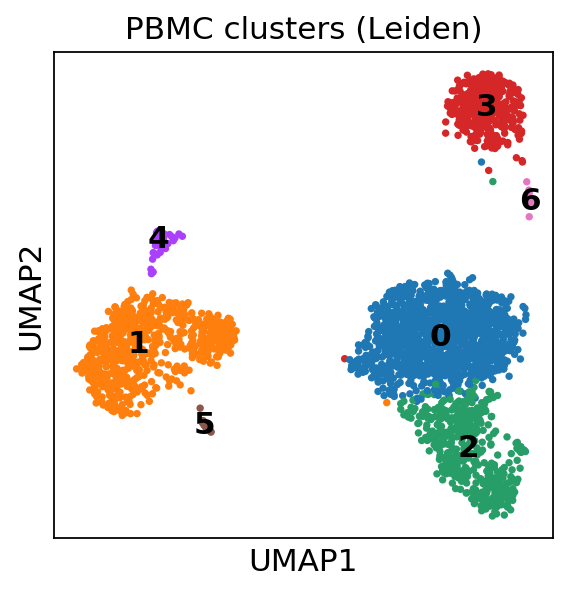

In [5]:
sc.pl.umap(adata, color='leiden', legend_loc='on data', title='PBMC clusters (Leiden)')

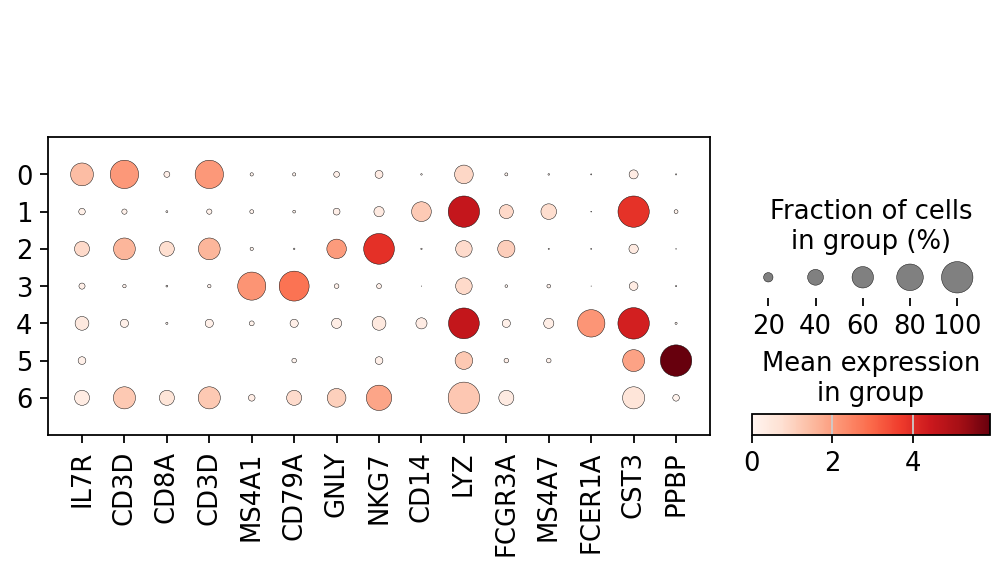

In [6]:
# Classic PBMC marker genes — useful for AI-assisted cell-type annotation of the clusters above
marker_genes = {
    'CD4 T cells': ['IL7R', 'CD3D'],
    'CD8 T cells': ['CD8A', 'CD3D'],
    'B cells': ['MS4A1', 'CD79A'],
    'NK cells': ['GNLY', 'NKG7'],
    'Monocytes (CD14)': ['CD14', 'LYZ'],
    'Monocytes (FCGR3A)': ['FCGR3A', 'MS4A7'],
    'Dendritic cells': ['FCER1A', 'CST3'],
    'Platelets': ['PPBP'],
}

flat_markers = [g for genes in marker_genes.values() for g in genes if g in adata.raw.var_names]
sc.pl.dotplot(adata, flat_markers, groupby='leiden', use_raw=True)

In [ ]:
# Open slot: paste marker output here and ask Claude to propose cell-type labels per cluster


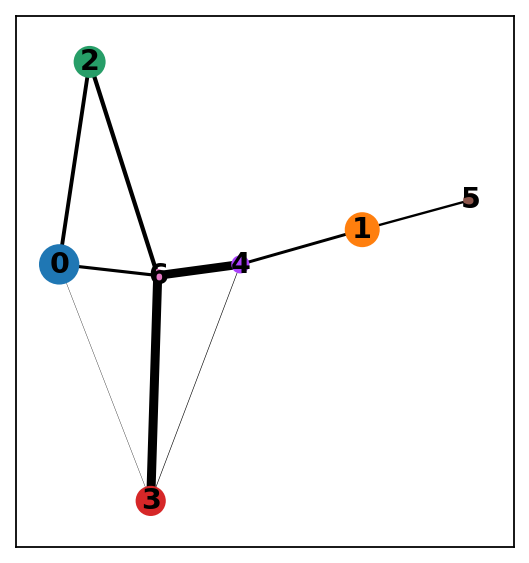

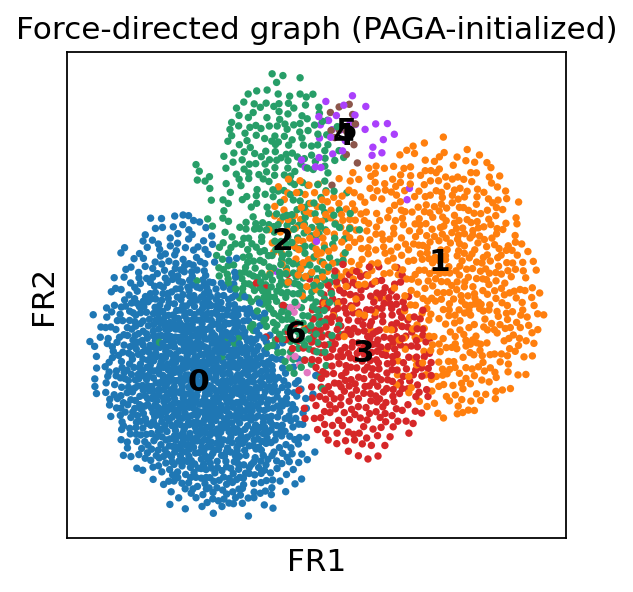

In [7]:
# Trajectory inference (PAGA)
sc.tl.paga(adata, groups='leiden')
sc.pl.paga(adata, plot=True)
sc.tl.draw_graph(adata, init_pos='paga')
sc.pl.draw_graph(adata, color='leiden', legend_loc='on data', title='Force-directed graph (PAGA-initialized)')

In [ ]:
# Open slot: ask Claude to restyle the trajectory plot or interpret it live


---
## Prompt cheat-sheet

Paste these into the chat with Claude:

1. *"Here's a figure from a paper [attach photo]. I have `adata`, an AnnData object, log-normalized, with `adata.obs['leiden']` clusters and UMAP coords in `adata.obsm['X_umap']`. Write matplotlib/seaborn code to replicate this figure using my data."*
2. *"Make the dot size scale with -log10(adjusted p-value) and color by log fold change, like a volcano plot."*
3. *"Here are the top marker genes for cluster 2: [paste list]. Based on known PBMC marker genes, what cell type does this look like?"*
4. *"Restyle this UMAP to match the color palette and legend placement in the photo I sent."*
5. *"Explain what this PAGA trajectory plot is showing, in plain language, for someone unfamiliar with trajectory inference."*
6. *"Here's a spatial figure from a paper [attach photo]. I have `vdata`, a Visium AnnData object, with spot coordinates in `vdata.obsm['spatial']`, the H&E image in `vdata.uns['spatial']`, and clusters in `vdata.obs['leiden']`. Write code to replicate this figure using my data."*

### Visium setup (run this once for Section 4)

/tmp/ipykernel_4190/2519242816.py:2: FutureWarning: The function visium_sge is deprecated and will be removed in the future. Use :func:`squidpy.datasets.visium` instead.
  vdata = sc.datasets.visium_sge(sample_id='V1_Breast_Cancer_Block_A_Section_1')


  0%|          | 0.00/9.50M [00:00<?, ?B/s]

  0%|          | 0.00/26.9M [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()
/usr/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_4190/2519242816.py:23: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(vdata_hvg, resolution=0.5)


AnnData object with n_obs × n_vars = 3798 × 22240
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatial', 'log1p', 'hvg'
    obsm: 'spatial', 'X_pca'
    layers: None (.X), 'counts'

Spots per cluster: {'0': 765, '1': 640, '2': 474, '3': 409, '4': 407, '5': 359, '6': 341, '7': 248, '8': 155}


/tmp/ipykernel_4190/2519242816.py:33: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(vdata, color='leiden', img_key='hires', title='Visium spots by cluster')


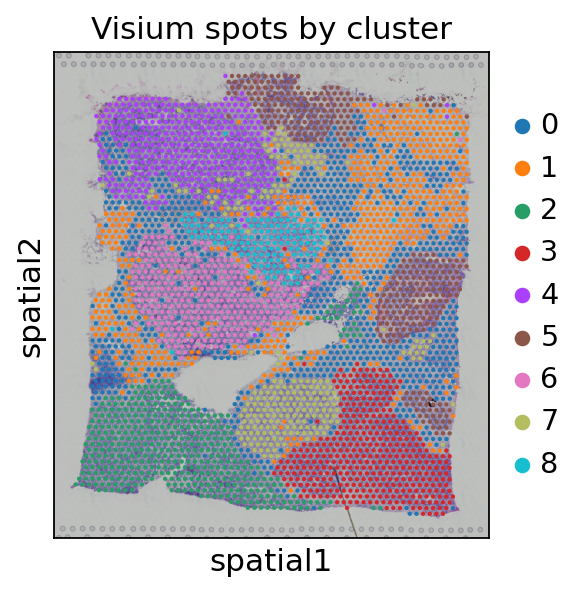

In [8]:
# Load a small public 10x Visium spatial dataset (downloads on first run)
vdata = sc.datasets.visium_sge(sample_id='V1_Breast_Cancer_Block_A_Section_1')
vdata.var_names_make_unique()

# Standard QC + preprocessing (same pattern as the PBMC data above)
sc.pp.filter_cells(vdata, min_counts=500)
sc.pp.filter_genes(vdata, min_cells=3)
vdata.var['mt'] = vdata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(vdata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
vdata = vdata[vdata.obs.pct_counts_mt < 20, :].copy()

vdata.layers['counts'] = vdata.X.copy()
sc.pp.normalize_total(vdata, target_sum=1e4)
sc.pp.log1p(vdata)
vdata.raw = vdata

sc.pp.highly_variable_genes(vdata, flavor='seurat', n_top_genes=2000)
vdata_hvg = vdata[:, vdata.var.highly_variable].copy()
sc.pp.scale(vdata_hvg, max_value=10)

sc.tl.pca(vdata_hvg, svd_solver='arpack')
sc.pp.neighbors(vdata_hvg, n_neighbors=10, n_pcs=30)
sc.tl.leiden(vdata_hvg, resolution=0.5)

# Carry clusters + PCA/UMAP back onto the full (non-HVG-subset) object used for spatial plotting
vdata.obs['leiden'] = vdata_hvg.obs['leiden']
vdata.obsm['X_pca'] = vdata_hvg.obsm['X_pca']

print(vdata)
print('\nSpots per cluster:', vdata.obs['leiden'].value_counts().to_dict())

# Baseline spatial plot: clusters overlaid on the H&E tissue image
sc.pl.spatial(vdata, color='leiden', img_key='hires', title='Visium spots by cluster')

**How to use:** show Claude a photo of a spatial figure from a paper (e.g. a gene expression heatmap over tissue, a spatial cluster map, a spot-neighborhood/niche plot), tell it you have `vdata` (structure described above), and paste the generated code into the next open slot. Same rule as Section 1 — the slots are generic, not tied to a figure type.

#### Visium figure replication — slot 1

In [27]:
# Visium figure replication — slot 1


#### Visium figure replication — slot 2

In [29]:
# Figure replication


#### Visium figure replication — slot 3

In [30]:
# Figure replication


---
## Prompt cheat-sheet

Paste these into the chat with Claude:

1. *"Here's a figure from a paper [attach photo]. I have `adata`, an AnnData object, log-normalized, with `adata.obs['leiden']` clusters and UMAP coords in `adata.obsm['X_umap']`. Write matplotlib/seaborn code to replicate this figure using my data."*
2. *"Make the dot size scale with -log10(adjusted p-value) and color by log fold change, like a volcano plot."*
3. *"Here are the top marker genes for cluster 2: [paste list]. Based on known PBMC marker genes, what cell type does this look like?"*
4. *"Restyle this UMAP to match the color palette and legend placement in the photo I sent."*
5. *"Explain what this PAGA trajectory plot is showing, in plain language, for someone unfamiliar with trajectory inference."*